# gradient-boosted tree

In [1]:
import pandas as pd

In [2]:
from dataengineers import Dataset

In [3]:
dataset = Dataset('train')
train, test = dataset.build_train_test()

In [4]:
exclude = ['id', 'target', 'delivery_start']

In [5]:
features = [c for c in train.columns if c not in exclude]

In [6]:
from models import XGB

In [7]:
xg = XGB(features)

In [8]:
xg.fit(train, test)

[0]	validation_0-rmse:152.02373	validation_1-rmse:62.93838
[100]	validation_0-rmse:114.40986	validation_1-rmse:53.14192
[200]	validation_0-rmse:91.53063	validation_1-rmse:48.26614
[300]	validation_0-rmse:76.70856	validation_1-rmse:46.14883
[400]	validation_0-rmse:66.75957	validation_1-rmse:45.80276
[500]	validation_0-rmse:59.88702	validation_1-rmse:45.94429
[560]	validation_0-rmse:56.71450	validation_1-rmse:46.26751


In [9]:
y_vals = xg.predict(test)

/home/matt/repos/nitor-comp/.venv/lib/python3.14/site-packages/xgboost/core.py:751: UserWarning: [12:59:54] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [10]:
from utils import rmse

In [11]:
rmse(test['target'], y_vals)

np.float64(45.730250245794316)

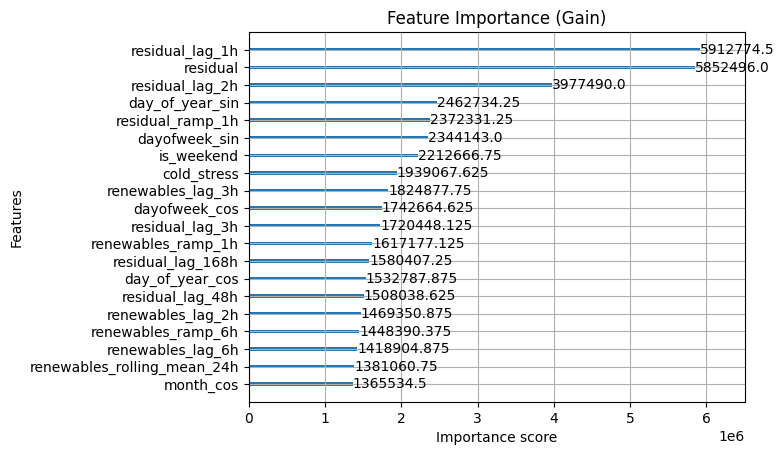

In [12]:
xg.stats()

In [13]:
ds2 = Dataset('test')

In [14]:
df_out = ds2.build_main()

In [15]:
y_out = xg.predict(df_out)

In [16]:
df_out['target'] = y_out

In [17]:
df_out.head()

,id,global_horizontal_irradiance,diffuse_horizontal_irradiance,direct_normal_irradiance,cloud_cover_total,cloud_cover_low,cloud_cover_mid,cloud_cover_high,precipitation_amount,visibility,...,residual_lag_12h,residual_lag_24h,residual_lag_48h,residual_lag_168h,residual_rolling_mean_6h,residual_rolling_mean_24h,residual_ramp_1h,residual_ramp_3h,residual_ramp_6h,target
0,133627,0.0,0.0,0.0,100.0,14.0,44.0,100.0,0.0,16600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,158.378113
1,133635,0.0,0.0,0.0,100.0,100.0,100.0,88.0,0.0,13800.0,...,NaN,NaN,NaN,NaN,51527.274200,51527.274200,-1463.3271,NaN,NaN,100.693939
2,133643,0.0,0.0,0.0,100.0,70.0,100.0,100.0,0.0,19700.0,...,NaN,NaN,NaN,NaN,50795.610650,50795.610650,-984.5816,NaN,NaN,154.580917
3,133651,0.0,0.0,0.0,99.0,13.0,99.0,94.0,0.0,16200.0,...,NaN,NaN,NaN,NaN,50223.528933,50223.528933,-489.7085,-2937.6172,NaN,153.412109
4,133659,0.0,0.0,0.0,96.0,0.0,96.0,79.0,0.0,14500.0,...,NaN,NaN,NaN,NaN,49815.060950,49815.060950,-121.4928,-1595.7829,NaN,158.114609


In [18]:
from utils import Submission

In [19]:
submit = Submission(df_out)

In [20]:
submit.process()

,id,target
0,133627,158.378113
2183,133629,62.045235
4366,133630,77.367340
10915,133631,59.147049
6549,133633,55.650764
...,...,...
4365,146774,52.197826
6548,146775,34.606678
13097,146776,34.435654
8731,146777,38.647392


In [21]:
submit.validate()

✅ Validation passed!


In [22]:
submit.dump()